In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path
from define_data_and_variables import adam_config, opes_config, data, adam_hash, hash_configs
import json
from matplotlib.collections import LineCollection


# TODO: fix so that it is easy to run either with fixed dF or updating dF. Need to increase maximum temp. Maybe increase number of shared chains for this as well.:)


In [2]:
base_dir = Path.cwd()
adam_config_ee = adam_config
adam_config_ee["mi"] = 10000
adam_hash_ee = hash_configs(adam_config_ee, data)

adam_dir = base_dir / f"output/{data["dn"]}/{adam_hash}"
adam_dir_ee = base_dir / f"output/{data['dn']}/{adam_hash_ee}"

sp = np.load(adam_dir / "adam_samples.npy")
energies = np.load(adam_dir / "adam_energies.npy")
d18o_energies = np.load(adam_dir_ee / "adam_d18o_energies.npy")

indices = np.argsort(energies)
sp = sp[indices][:opes_config["hmcc"]["nch"]]
opes_config["hmcc"]["sp"] = np.ascontiguousarray(sp)
opes_config["df"] = np.min(d18o_energies) * (opes_config["bs"] - 1)
opes_config["dfn"] = np.exp(-opes_config["df"])*opes_config["dfd"]

opes_hash = hash_configs(opes_config, data)
output_dir = adam_dir / f"{opes_hash}"

hmc_config = opes_config["hmcc"]

In [3]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))
temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [5]:
starting_energies = np.load(adam_dir / "adam_energies.npy")
starting_points= np.load(adam_dir / "adam_samples.npy")

idx = np.argsort(starting_energies)
starting_energies_sorted = starting_energies[idx]

sp_energies = starting_energies_sorted[:hmc_config["nch"]]
sp = starting_points[idx][:hmc_config["nch"], :]

(5, 51)


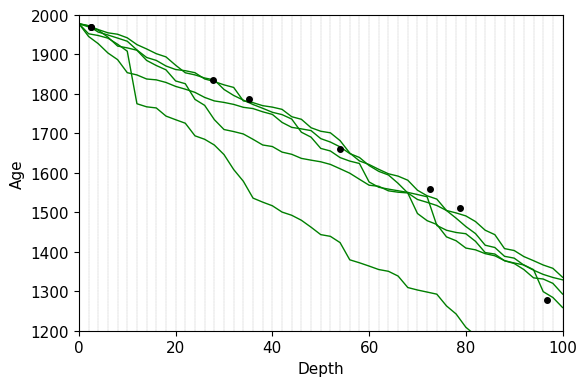

In [ ]:

cumulative_sums = np.cumsum(sp, axis=1) * data["dc"]
zeros = np.zeros((*sp.shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(sp)
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
# plt.savefig(f"{adam_dir}/sp_age_depth.jpg")
plt.show()

(100, 51)


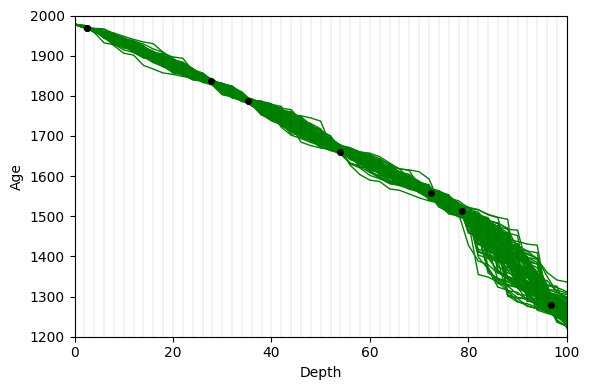

In [7]:

cumulative_sums = np.cumsum(starting_points, axis=1) * data["dc"]
zeros = np.zeros((*starting_points.shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(starting_points)
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{adam_dir}/all_sp_age_depth.jpg")
plt.show()

In [8]:
samples = np.load(output_dir / "samples.npy")

In [9]:
print(output_dir)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_OPES_normal_clean_d18o\output\dayu06\14339e1ad9\d07e6e1ed0


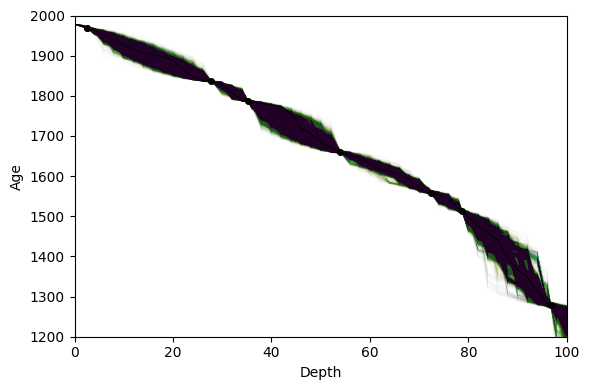

In [9]:
short_samples = samples
cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
zeros = np.zeros((*short_samples.shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(short_samples[0,:,0])

for i in range(hmc_config["nch"]):
    lines = np.stack(
        [np.column_stack((data["cs"], model_ages[i, j])) for j in range(num_samples)]
    )

    lc = LineCollection(
        lines,
        colors=colors[i],
        linewidths=0.05,
        alpha=0.05
    )
    ax.add_collection(lc)
    ax.autoscale()

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{output_dir}/age_depth_samples.jpg")
plt.show()

In [10]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(short_samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk   ess_tail  \
x[0]    2.86  0.42    2.06     3.66       0.00     0.00  160281.19  155824.64   
x[1]    4.71  1.36    2.19     7.39       0.00     0.01  172933.38  127265.18   
x[2]    5.69  2.17    1.49     9.55       0.01     0.01   90662.34   86534.93   
x[3]    6.08  2.71    1.26    10.91       0.01     0.01   64192.98   84063.20   
x[4]    5.93  2.89    1.06    10.90       0.01     0.01   46980.52   94345.42   
x[5]    5.45  3.01    0.91    11.03       0.01     0.01   56139.84   80847.84   
x[6]    5.61  3.18    0.92    11.58       0.01     0.01   57339.86  103614.88   
x[7]    4.98  2.95    0.75    10.46       0.01     0.01   43982.94   92829.97   
x[8]    5.34  3.05    0.80    10.75       0.02     0.01   31419.24   75970.61   
x[9]    6.28  3.66    0.88    12.92       0.03     0.01   12343.46   57583.00   
x[10]   5.26  2.99    0.78    10.76       0.01     0.01   45477.68   98121.92   
x[11]   5.18  3.25    0.77  

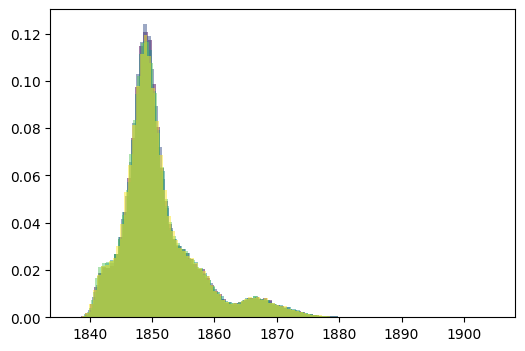

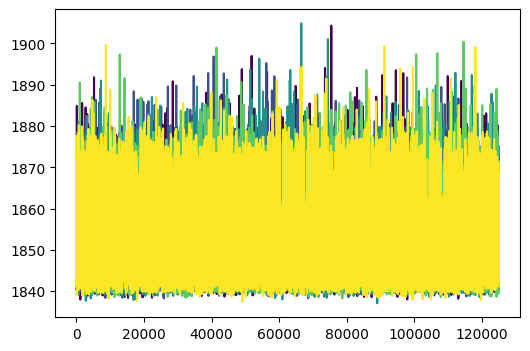

In [71]:
index = 12
interesting_depth = index * data["dc"]
CV_values = data["th"] - data["dc"] * np.sum(samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.savefig(f"{output_dir}/sampling_along_depth_evolution_{interesting_depth}.jpg")
plt.show()

In [11]:
bias_values = np.load(f"{output_dir}/bias.npy")
energy_values = np.load(f"{output_dir}/energy.npy")

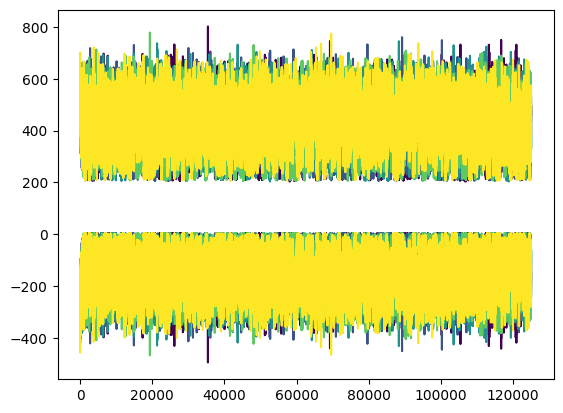

In [13]:
plt.figure()
for i in range(hmc_config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
    plt.plot(energy_values[i,:], color = colors[i])
plt.savefig(f"{output_dir}/energy_and_bias.jpg")
plt.show()

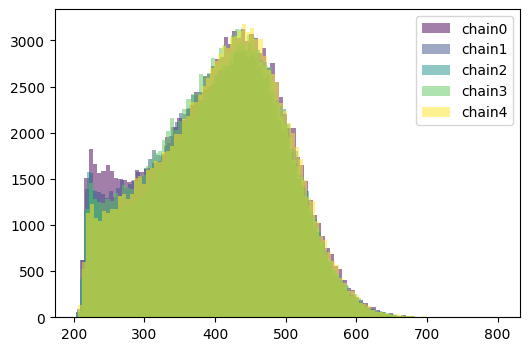

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
plt.legend()
plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   

In [12]:
resampled_samples = []
cutout = 10000
weights = np.exp(bias_values)
local_indices_list = []
for i in range(hmc_config["nch"]):
    weights_i = weights[i, cutout:] / sum(weights[i, cutout:])

    indices = np.random.choice(
        np.arange(cutout, len(weights_i) + cutout),
        size=int(len(weights_i)),
        replace=True,
        p=weights_i,
    )
    resampled_samples.append(samples[i, indices, :])
    print(f"Chain {i} done resampling")

resampled_samples = np.array(resampled_samples)

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling


11500.0


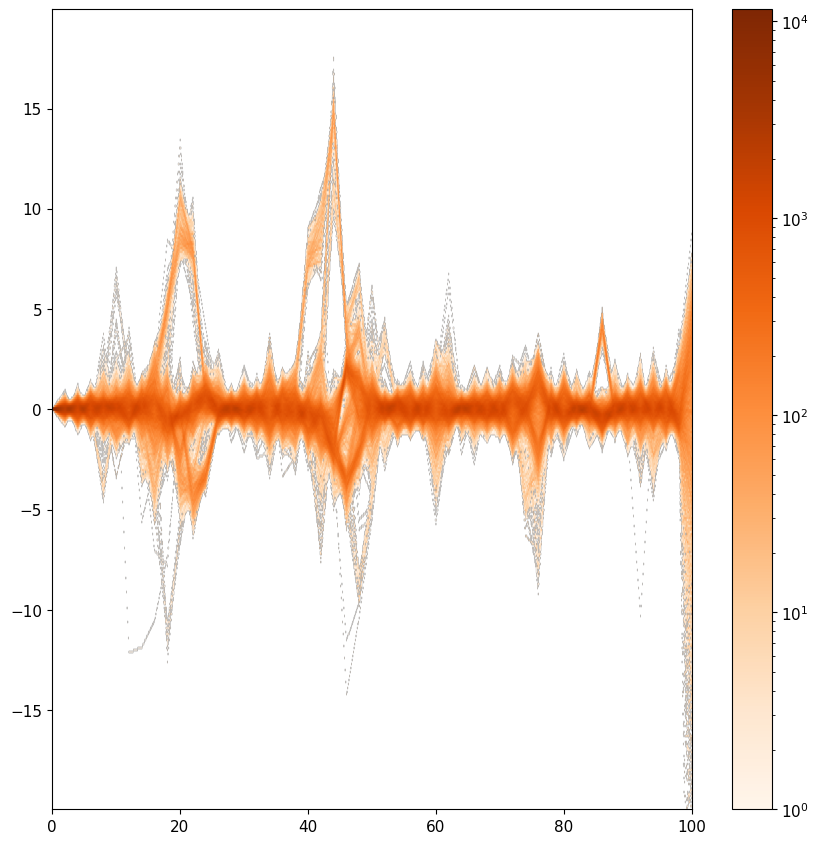

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

X = np.loadtxt('resampled_samples.txt').T

D, N = X.shape

# Depth grid (0:2:2*D)'
depth = np.arange(0, 2 * D + 1, 2)

age = np.vstack([
    np.zeros((1, N)),
    data["th"] - np.cumsum(X, axis=0)
])

age_mean = np.mean(age, axis = 1)
norm_age = age- age_mean.reshape(51, 1)

# Time bins
dt = 0.1
t_edges = np.arange(-20, 20 + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, 2 * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)

# Main loop (interp1 + histcounts)
for i in range(Z):
    a = np.array([
        np.interp(z[i], depth, norm_age[:, j])
        for j in range(N)
    ])
    C[i, :], _ = np.histogram(a, bins=t_edges)

# ------------------
# Plotting
# ------------------
plt.figure(1, figsize=(10, 10), dpi=100)
plt.clf()

sub = [0.10, 0.10, 0.80, 0.80]
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

plt.set_cmap(plt.cm.Oranges)

print(np.nanmax(C))

ax = plt.axes(sub)
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

plt.colorbar(im)
plt.show()


In [ ]:
resampled_samples_new = resampled_samples[0, ::10]

np.savetxt("resampled_samples.txt", resampled_samples_new)

In [16]:
d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")

In [17]:
print("Reweighting energies for each temp\n")
nt = opes_config["nt"]

temp_centers = np.linspace(1, opes_config["ebt"], nt)
temp_colors = plt.cm.viridis(np.linspace(0,1, nt))

# Compute betas
betas = 1.0 / temp_centers

# Initial beta
energy_samples = []
weights = []
cutout = 100

for j in range(nt):
    temp_energy_samples = []
    weights = np.exp(-(betas[j] - 1) * d18o_energy_values + bias_values)
    for i in range(hmc_config["nch"]):
            weights_i = weights[i, cutout:] / sum(weights[i, cutout:])
            indices = np.random.choice(
                np.arange(cutout, len(weights_i) + cutout),
                size=int(len(weights_i)),
                replace=True,
                p=weights_i,
            )
            temp_energy_samples.append(energy_values[i, indices])

    print(f"Temp {j} done resampling")
    energy_samples.append(temp_energy_samples)

energy_samples = np.array(energy_samples)
print(np.shape(energy_samples))

Reweighting energies for each temp

Temp 0 done resampling
Temp 1 done resampling
Temp 2 done resampling
Temp 3 done resampling
Temp 4 done resampling
Temp 5 done resampling
Temp 6 done resampling
Temp 7 done resampling
Temp 8 done resampling
Temp 9 done resampling
Temp 10 done resampling
Temp 11 done resampling
Temp 12 done resampling
Temp 13 done resampling
Temp 14 done resampling
Temp 15 done resampling
Temp 16 done resampling
Temp 17 done resampling
Temp 18 done resampling
Temp 19 done resampling
Temp 20 done resampling
Temp 21 done resampling
Temp 22 done resampling
Temp 23 done resampling
Temp 24 done resampling
Temp 25 done resampling
Temp 26 done resampling
Temp 27 done resampling
Temp 28 done resampling
Temp 29 done resampling
Temp 30 done resampling
Temp 31 done resampling
Temp 32 done resampling
Temp 33 done resampling
Temp 34 done resampling
Temp 35 done resampling
Temp 36 done resampling
Temp 37 done resampling
Temp 38 done resampling
Temp 39 done resampling
(40, 5, 124900

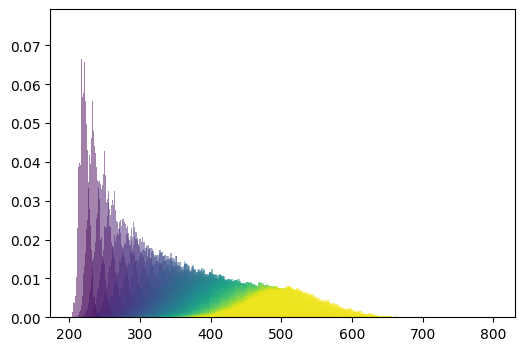

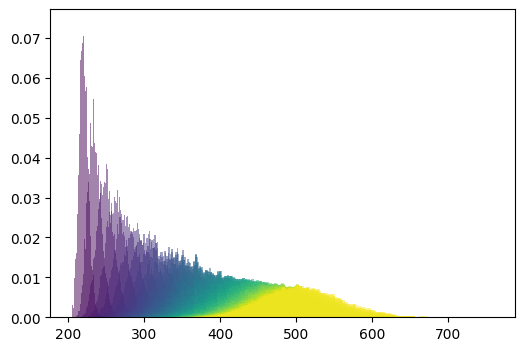

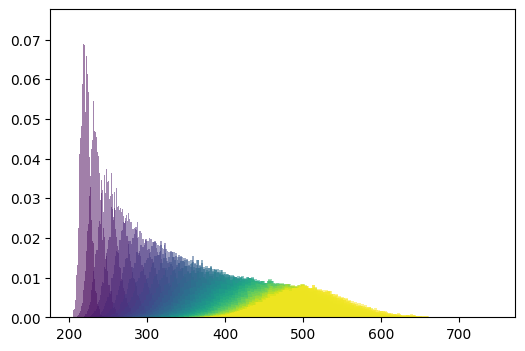

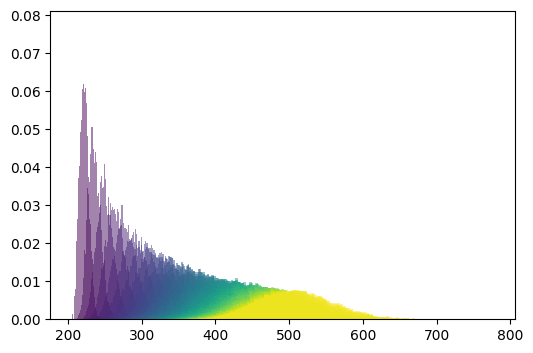

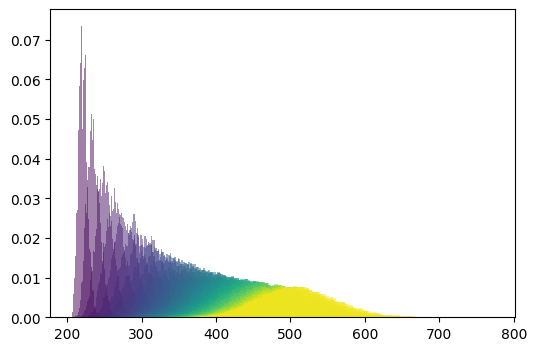

In [18]:
limit_grid = np.linspace(80, 190, 100)
bin_grid = limit_grid[:-1]
mean_energies = np.zeros((hmc_config["nch"], nt))
energy_stds = np.zeros((hmc_config["nch"], nt))

for k in range(hmc_config["nch"]):
    fig, ax = plt.subplots(figsize=(6, 4))
    for j in range(nt):
        ax.hist(energy_samples[j, k], bins = 100, color = temp_colors[j], label = f"temp {temp_centers[j]}", alpha = 0.5, density = True)
        mean_energies[k,j]  = np.mean(energy_samples[j, k])
        energy_stds[k,j]  = np.std(energy_samples[j, k])
    
    plt.savefig(f"{output_dir}/temp_pic_chain_{k}.jpg")
    plt.show()

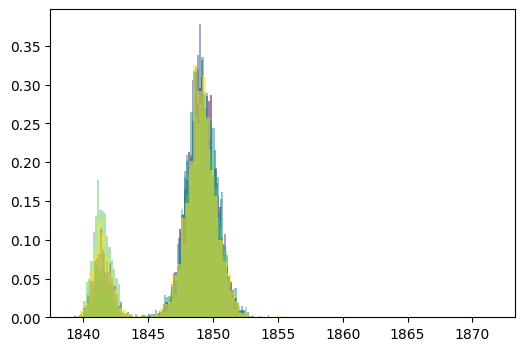

In [72]:
CV_values = data["th"] - data["dc"] * np.sum(resampled_samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"{output_dir}/resampling_along_depth_{interesting_depth}.jpg")
plt.show()

In [55]:
short_resampled_samples = resampled_samples[:, :, :]
cumulative_sums = np.cumsum(short_resampled_samples, axis=2) * data["dc"]
zeros = np.zeros((*short_resampled_samples.shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["th"] - age_offsets
num_samples = len(short_resampled_samples[0,:,0])


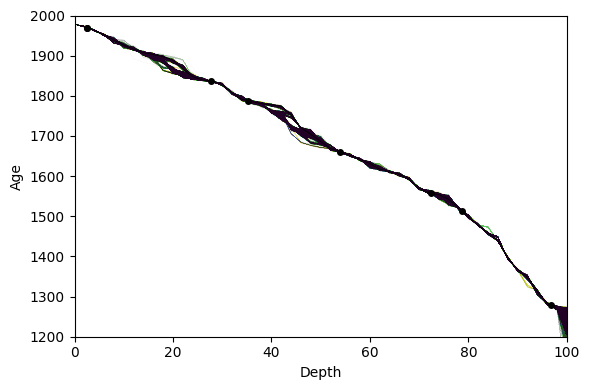

In [20]:

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    lines = np.stack(
        [np.column_stack((data["cs"], model_ages[i, j])) for j in range(num_samples)]
    )

    lc = LineCollection(
        lines,
        colors=colors[i],
        linewidths=0.05,
        alpha=0.05
    )
    ax.add_collection(lc)
    ax.autoscale()

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{output_dir}/age_depth.jpg")
plt.show()

C:\Users\hanna\AppData\Local\Temp\ipykernel_9052\561290193.py:12: RuntimeWarning: invalid value encountered in divide
  H = H / H.max(axis=1, keepdims=True)


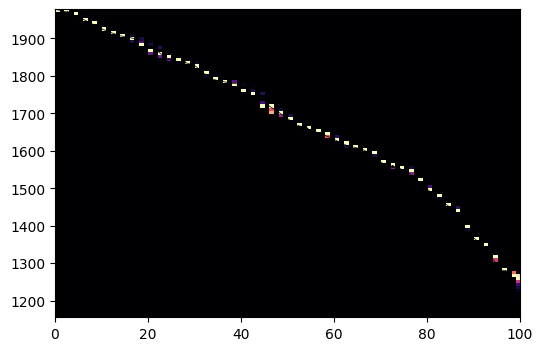

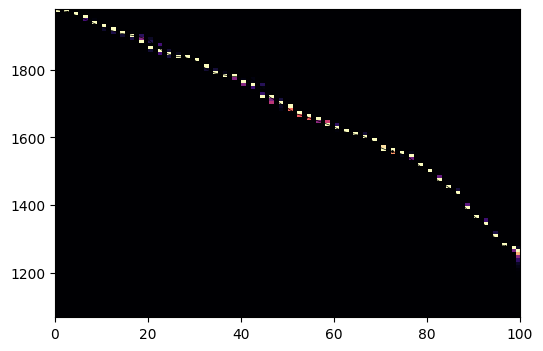

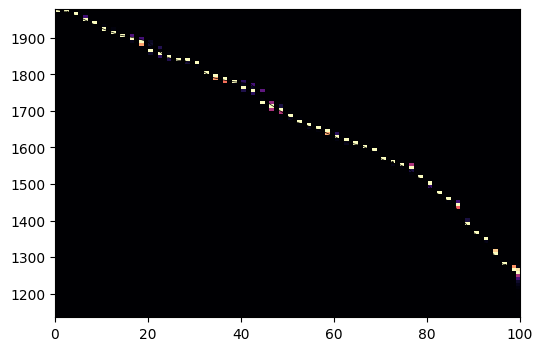

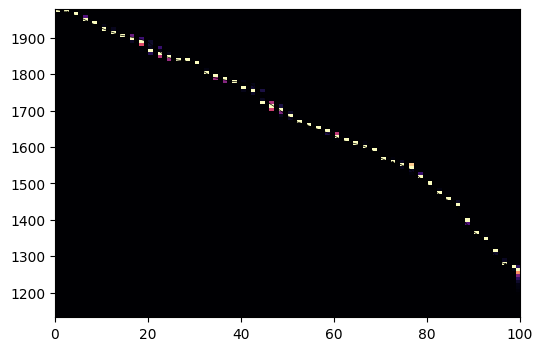

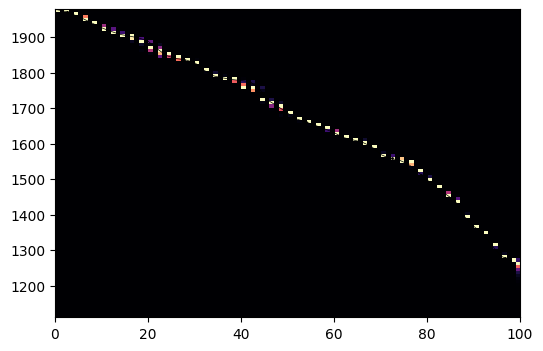

In [ ]:

for i in range(hmc_config["nch"]):
    fig, ax = plt.subplots(figsize=(6, 4))

    xs = np.repeat(data["cs"][None, :], num_samples, axis=0)
    ys = model_ages[i, :]
    H, xedges, yedges = np.histogram2d(
        xs.ravel(),
        ys.ravel(),
        bins=(100, 100),
    )

    H = H / H.max(axis=1, keepdims=True)
    H = np.nan_to_num(H)
    H = np.log1p(H)
    
    ax.imshow(
        H.T,
        origin="lower",
        aspect="auto",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap="magma"
    )

    plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=1)
    plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)

    plt.show()


# TODO: CONTINUE HERE. It actually looks like all of them are working!!!:) Just find a good way to plot things! And then write<3



In [21]:
base_dir = Path.cwd()

df = np.load(f"{output_dir}/df.npy")
print(df.shape)

(5, 125000, 40)


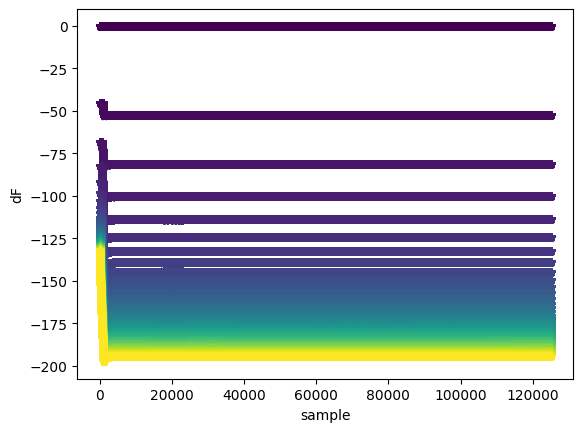

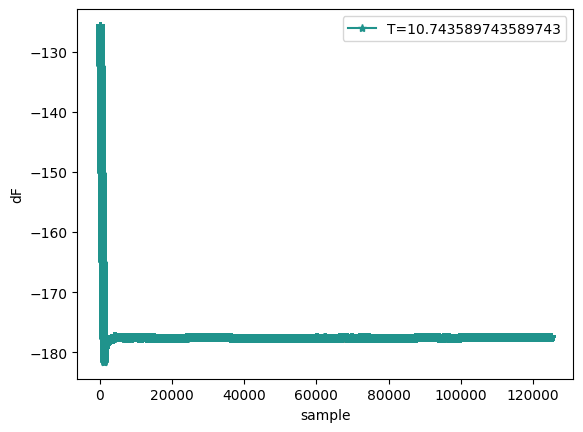

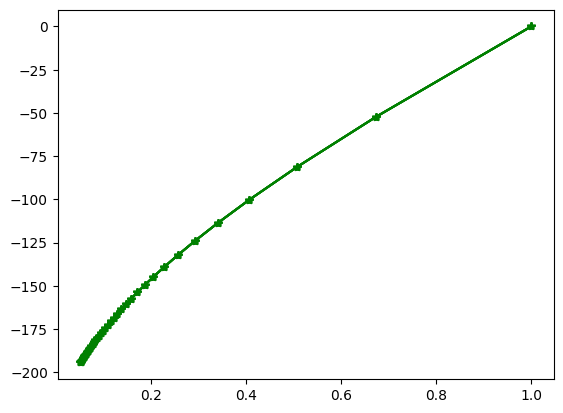

In [22]:
fig, ax = plt.subplots()
chain = 0

x = np.linspace(0, hmc_config["ns"]-1, hmc_config["ns"])
for k in range(nt):
    sample_delta_F = np.squeeze(df[chain, :, k])
    ax.plot(x[:], sample_delta_F, '*-', color = temp_colors[k], label = f"T={temp_centers[k]}")

plt.xlabel(f"sample")
plt.ylabel("dF")
plt.savefig(f"{output_dir}/df.jpg")
plt.show()

fig, ax = plt.subplots()
sample_delta_F = np.squeeze(df[chain, :, int(opes_config["nt"]/2)])
ax.plot(x, sample_delta_F, '*-', color = temp_colors[int(opes_config["nt"]/2)], label = f"T={temp_centers[int(opes_config["nt"]/2)]}")
plt.legend()
plt.xlabel(f"sample")
plt.ylabel(f"dF")
plt.savefig(f"{output_dir}/df_last.jpg")
plt.show()

plt.figure()
for i in range(hmc_config["nch"]):
    plt.plot(betas, df[i, -1, :], marker = '*', color = "green")

plt.savefig(f"{output_dir}/df_to_beta.jpg")
plt.show()